In [1]:
# python notebook for Make Your Own Neural Network
# (c) Tariq Rashid, 2016
# license is GPLv2

In [1]:
import numpy
# scipy.special for the sigmoid function expit()
import scipy.special

In [2]:
# neural network class definition
class neuralNetwork:
    
    
    # initialise the neural network
    def __init__(self, inputnodes, hiddennodes, outputnodes, learningrate):
        # set number of nodes in each input, hidden, output layer
        self.inodes = inputnodes
        self.hnodes = hiddennodes
        self.onodes = outputnodes
        
        # link weight matrices, wih and who
        # weights inside the arrays are w_i_j, where link is from node i to node j in the next layer
        # w11 w21
        # w12 w22 etc 
        self.wih = numpy.random.normal(0.0, pow(self.inodes, -0.5), (self.hnodes, self.inodes))
        self.who = numpy.random.normal(0.0, pow(self.hnodes, -0.5), (self.onodes, self.hnodes))

        # learning rate
        self.lr = learningrate
        
        # activation function is the sigmoid function
        self.activation_function = lambda x: scipy.special.expit(x)
        
        pass

    
    # train the neural network
    def train(self, inputs_list, targets_list):
        # convert inputs list to 2d array
        inputs = numpy.array(inputs_list, ndmin=2).T
        targets = numpy.array(targets_list, ndmin=2).T
        
        # calculate signals into hidden layer
        hidden_inputs = numpy.dot(self.wih, inputs)
        # calculate the signals emerging from hidden layer
        hidden_outputs = self.activation_function(hidden_inputs)
        
        # calculate signals into final output layer
        final_inputs = numpy.dot(self.who, hidden_outputs)
        # calculate the signals emerging from final output layer
        final_outputs = self.activation_function(final_inputs)
        
        # output layer error is the (target - actual)
        output_errors = targets - final_outputs
        # hidden layer error is the output_errors, split by weights, recombined at hidden nodes
        hidden_errors = numpy.dot(self.who.T, output_errors) 
        
        # update the weights for the links between the hidden and output layers
        self.who += self.lr * numpy.dot((output_errors * final_outputs * (1.0 - final_outputs)), numpy.transpose(hidden_outputs))
        
        # update the weights for the links between the input and hidden layers
        self.wih += self.lr * numpy.dot((hidden_errors * hidden_outputs * (1.0 - hidden_outputs)), numpy.transpose(inputs))
        
        pass

    
    # query the neural network
    def query(self, inputs_list):
        # convert inputs list to 2d array
        inputs = numpy.array(inputs_list, ndmin=2).T
        
        # calculate signals into hidden layer
        hidden_inputs = numpy.dot(self.wih, inputs)
        # calculate the signals emerging from hidden layer
        hidden_outputs = self.activation_function(hidden_inputs)
        
        # calculate signals into final output layer
        final_inputs = numpy.dot(self.who, hidden_outputs)
        # calculate the signals emerging from final output layer
        final_outputs = self.activation_function(final_inputs)
        
        return final_outputs

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from pydub import AudioSegment

c:\Users\shiba\anaconda3\envs\lab\lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


In [4]:
sounds = AudioSegment.from_file(r"C:\Users\shiba\OneDrive\Desktop\code\音響工学特論\20240516_132455.wav", "r")

# 基本情報の表示
print(f"channel: {sounds.channels}")
print(f"frame rate: {sounds.frame_rate}")
print(f"duration: {sounds.duration_seconds} s")



channel: 1
frame rate: 44100
duration: 5.994331065759638 s


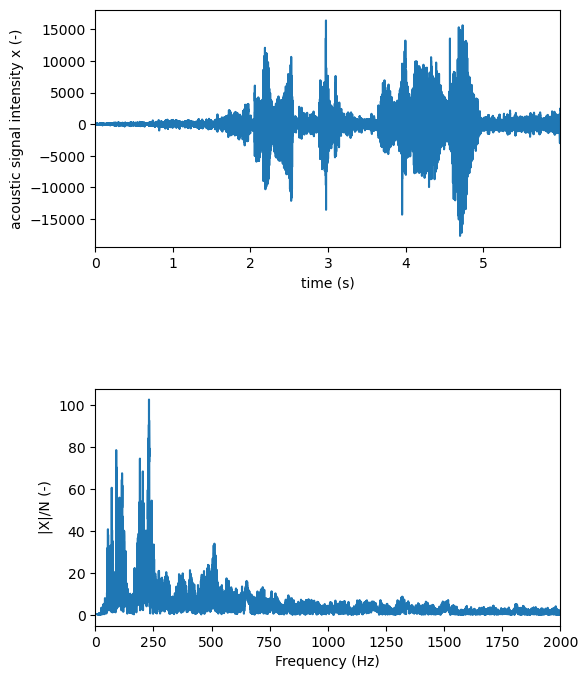

In [5]:
# ただし、今回の場合はモノラルを想定。つまり、,sound.channels = 1
sig = np.array(sounds.get_array_of_samples())[::sounds.channels]
dt= 1.0/sounds.frame_rate # サンプリング時間

# 時間アレイを作る
tms = 0.0 # サンプル開始時間を0にセット
tme = sounds.duration_seconds # サンプル終了時刻
tm = np.linspace(tms, tme, len(sig), endpoint=False) # 時間narrayを取得

# 離散フーリエ変換(DFT)
N = len(sig)
X = np.fft.fft(sig)
f = np.fft.fftfreq(N, dt)

# データをプロット
fig, (ax01, ax02) = plt.subplots(nrows=2, figsize=(6, 8))
plt.subplots_adjust(wspace=0.0, hspace=0.6)

ax01.set_xlim(tms, tme)
ax01.set_xlabel("time (s)")
ax01.set_ylabel("acoustic signal intensity x (-)")
ax01.plot(tm, sig) # 入力信号

ax02.set_xlim(0, 2000)
ax02.set_xlabel("Frequency (Hz)")
ax02.set_ylabel("|X|/N (-)")

a = f[0:N//2]
b = np.abs(X[0:N//2])/N

ax02.plot(a, b) # 振幅スペクトル

plt.show()

In [10]:
# number of input, hidden and output nodes
input_nodes = 132175
hidden_nodes = 3
output_nodes = 3

# learning rate is 0.3
learning_rate = 0.3

# create instance of neural network
n = neuralNetwork(input_nodes,hidden_nodes,output_nodes, learning_rate)

In [9]:
print(b.shape)

(132175,)


In [8]:
type(b)

numpy.ndarray

In [14]:
# test query (doesn't mean anything useful yet)
n.query([a])

array([[0.42442336],
       [0.52915847],
       [0.45807225]])

In [ ]:
# train the neural network

# epochs is the number of times the training data set is used for training
epochs = 5

for e in range(epochs):
    # go through all records in the training data set
    for record in a:
        # split the record by the ',' commas
        all_values = record.split(',')
        # scale and shift the inputs
        inputs = (numpy.asfarray(all_values[1:]) / 255.0 * 0.99) + 0.01
        # create the target output values (all 0.01, except the desired label which is 0.99)
        targets = numpy.zeros(output_nodes) + 0.01
        # all_values[0] is the target label for this record
        targets[int(all_values[0])] = 0.99
        n.train(inputs, targets)
        pass
    pass